# Bank Loan Analysis Report 

### Import Libraries

In [50]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
import plotly.express as px

### import data 

In [75]:
df = pd.read_excel("C:/Users/taufe/Downloads/financial_loan.xlsx")

### read data

In [77]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [78]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,2021-07-11,2021-05-16,2021-05-16,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,2021-10-11,2021-04-16,2021-05-16,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,2021-09-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,2021-10-11,2021-05-16,2021-05-16,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,2021-07-11,2021-05-16,2021-05-16,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


### Matadata of Data 

In [79]:
print("NO OF ROWS:",df.shape[0])

NO OF ROWS: 38576


In [80]:
print("NO OF COLUMNS:",df.shape[1])

NO OF COLUMNS: 24


In [81]:
df.info

<bound method DataFrame.info of             id address_state application_type emp_length  \
0      1077430            GA       INDIVIDUAL   < 1 year   
1      1072053            CA       INDIVIDUAL    9 years   
2      1069243            CA       INDIVIDUAL    4 years   
3      1041756            TX       INDIVIDUAL   < 1 year   
4      1068350            IL       INDIVIDUAL  10+ years   
...        ...           ...              ...        ...   
38571   803452            NJ       INDIVIDUAL   < 1 year   
38572   970377            NY       INDIVIDUAL    8 years   
38573   875376            CA       INDIVIDUAL    5 years   
38574   972997            NY       INDIVIDUAL    5 years   
38575   682952            NY       INDIVIDUAL    4 years   

                             emp_title grade home_ownership issue_date  \
0                                Ryder     C           RENT 2021-02-11   
1                       MKC Accounting     E           RENT 2021-01-01   
2                Chemat T

### Data Types

In [82]:
df.dtypes

id                                int64
address_state                    object
application_type                 object
emp_length                       object
emp_title                        object
grade                            object
home_ownership                   object
issue_date               datetime64[ns]
last_credit_pull_date    datetime64[ns]
last_payment_date        datetime64[ns]
loan_status                      object
next_payment_date        datetime64[ns]
member_id                         int64
purpose                          object
sub_grade                        object
term                             object
verification_status              object
annual_income                   float64
dti                             float64
installment                     float64
int_rate                        float64
loan_amount                       int64
total_acc                         int64
total_payment                     int64
dtype: object

In [83]:
df.describe()

,id,issue_date,last_credit_pull_date,last_payment_date,next_payment_date,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,38576,38576,38576,38576,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,2021-07-16 02:31:35.562007040,2021-06-08 13:36:34.193280512,2021-06-26 09:52:08.909166080,2021-07-26 20:42:20.605557760,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
min,5.473400e+04,2021-01-01 00:00:00,2021-01-08 00:00:00,2021-01-08 00:00:00,2021-02-08 00:00:00,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,2021-04-11 00:00:00,2021-04-15 00:00:00,2021-03-16 00:00:00,2021-04-16 00:00:00,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,2021-07-11 00:00:00,2021-05-16 00:00:00,2021-06-14 00:00:00,2021-07-14 00:00:00,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,2021-10-11 00:00:00,2021-08-13 00:00:00,2021-09-15 00:00:00,2021-10-15 00:00:00,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,2021-12-12 00:00:00,2022-01-20 00:00:00,2021-12-15 00:00:00,2022-01-15 00:00:00,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000
std,2.113246e+05,NaN,NaN,NaN,NaN,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777


# ANALYSIS 

### Total Loan Applications

In [84]:
total_loan_applications = df['id'].count()
print("Total Loan Application:",total_loan_applications)

Total Loan Application: 38576


### MTD Total Loan Application 

In [85]:
Latest_issue_date = df['issue_date'].max()
Latest_year = Latest_issue_date.year
Latest_month = Latest_issue_date.month

MTD_DATA = df[(df['issue_date'].dt.year == Latest_year) & (df['issue_date'].dt.month == Latest_month)]

MTD_Loan_Application = MTD_DATA['id'].count()

print(f"MTD Loan Application(for {Latest_issue_date.strftime('%B %Y')}):{MTD_Loan_Application}")
print(f"MTD Loan Application:{MTD_Loan_Application}")

MTD Loan Application(for December 2021):4314
MTD Loan Application:4314


### Total Funded Amount 

In [86]:
Total_Funded_Amount = df['loan_amount'].sum()
Total_Funded_Amount_Million = Total_Funded_Amount / 1000000
print("Total Funded Amount: ${:.2f}M".format(Total_Funded_Amount_Million))

Total Funded Amount: $435.76M


### MTD- Total Funded Amount 

In [87]:
Latest_issue_date = df['issue_date'].max()
latest_year = Latest_issue_date.year
latest_month = Latest_issue_date.month

MTD_DATA = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

MTD_Total_Funded_Amount = MTD_DATA['loan_amount'].sum()
MTD_Total_Funded_Amount_Millions = MTD_Total_Funded_Amount/1000000
print("MTD Total Funded Amount: ${:.2f}M".format(MTD_Total_Funded_Amount_Millions))

MTD Total Funded Amount: $53.98M


### Total Amount Received

In [88]:
Total_Amount_recevied = df['total_payment'].sum()
Total_Amount_recevied_million = Total_Amount_recevied / 1000000
print("Total Amount Received: ${:.2f}M".format(Total_Amount_recevied_million))

Total Amount Received: $473.07M


### MTD-Total Amount Received

In [89]:
Latest_issue_date = df['issue_date'].max()
latest_year = Latest_issue_date.year
latest_month = Latest_issue_date.month 

MTD_DATA = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

MTD_Total_amount_received = MTD_DATA['total_payment'].sum()
MTD_Total_amount_received_million = MTD_Total_amount_received/1000000

print("MTD Total Amount Received: ${:.2f}M".format(MTD_Total_amount_received_million))

MTD Total Amount Received: $58.07M


### AVERAGE INTEREST RATE

In [90]:
Average_interest_rate = df['int_rate'].mean()*100
print("Average Interest rate:{:.2f}%".format(Average_interest_rate))

Average Interest rate:12.05%


### AVERAGE Debt-TO-Income Ratio(DTI)

In [91]:
Average_debt_to_income_ratio = df['dti'].mean()*100
print("Average dti:{:.2f}%".format(Average_debt_to_income_ratio))

Average dti:13.33%


In [98]:
df['loan_status'].value_counts()

loan_status
fully paid     32145
charged off     5333
current         1098
Name: count, dtype: int64

### Good Loan Metrix

In [100]:

good_loans = df[df['loan_status'].isin(["fully paid","current"])]

total_loan_applications = df['id'].count()

good_loan_applications = good_loans['id'].count()
good_loan_funded_amount = good_loans['loan_amount'].sum()
good_loan_received_amount = good_loans['total_payment'].sum()

good_loan_funded_amount_million = good_loan_funded_amount/1000000
good_loan_received_amount_million = good_loan_received_amount/1000000

good_loan_percentage = (good_loan_applications/total_loan_applications)*100

print("good loan application:",good_loan_applications)
print("good loan funded amount:${:.2f}M".format(good_loan_funded_amount_million))
print("good loan received amount:${:.2f}M".format(good_loan_received_amount_million))
print("good loan percentage:{:.2f}%".format(good_loan_percentage))

good loan application: 33243
good loan funded amount:$370.22M
good loan received amount:$435.79M
good loan percentage:86.18%


### bad Loan Metrix

In [102]:
bad_loans = df[df['loan_status'].isin(["charged off"])]

total_loan_applications = df['id'].count()

bad_loan_applications = bad_loans['id'].count()
bad_loan_funded_amount = bad_loans['loan_amount'].sum()
bad_loan_received_amount = bad_loans['total_payment'].sum()

bad_loan_funded_amount_million = bad_loan_funded_amount/1000000
bad_loan_received_amount_million = bad_loan_received_amount/1000000
bad_loan_percentage = (bad_loan_applications/total_loan_applications)*100
print("bad loan application:",bad_loan_applications)
print("bad loan funded amount:${:.2f}M".format(bad_loan_funded_amount_million))
print("bad loan received amount:${:.2f}M".format(bad_loan_received_amount_million))
print("bad loan percentage:{:.2f}%".format(bad_loan_percentage))
    

bad loan application: 5333
bad loan funded amount:$65.53M
bad loan received amount:$37.28M
bad loan percentage:13.82%


### Month trends by issue date for the total funded amount

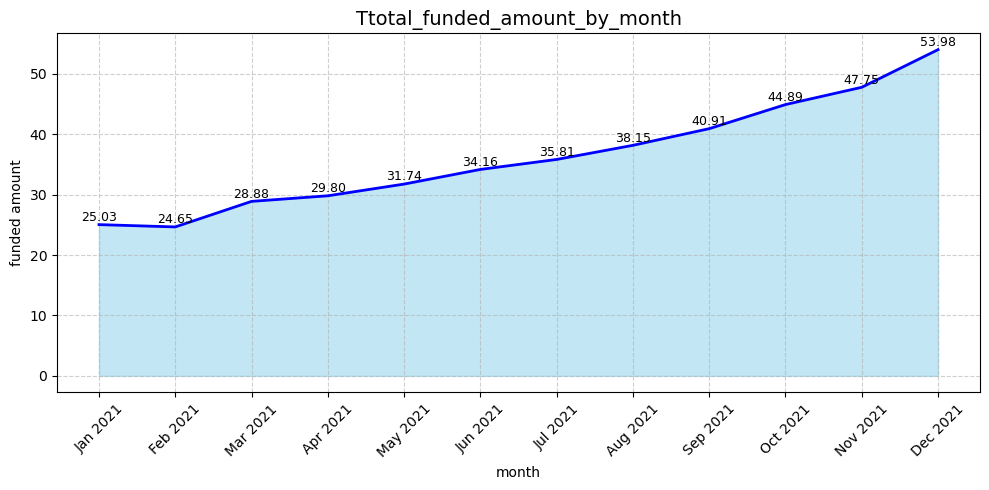

In [106]:
monthly_funded = (
    df.sort_values('issue_date')
    .assign(month_name=lambda x : x ['issue_date'].dt.strftime("%b %Y"))
    .groupby('month_name',sort=False)['loan_amount']
    .sum()
    .div(1000000)
    .reset_index(name='loan_amount_million')
)
plt.figure(figsize=(10,5))
plt.fill_between(monthly_funded['month_name'],monthly_funded['loan_amount_million'],color='skyblue',alpha=0.5)
plt.plot(monthly_funded['month_name'],monthly_funded['loan_amount_million'],color='blue',linewidth=2)

for i, row in monthly_funded.iterrows():
    plt.text(i,row['loan_amount_million'] + 0.1,f"{row['loan_amount_million']:.2f}",
             ha='center',va='bottom',fontsize=9,rotation=0,color='black')
plt.title('total_funded_amount_by_month',fontsize=14)
plt.xlabel('month')
plt.ylabel('funded amount')
plt.xticks(ticks=range(len(monthly_funded)),label=monthly_funded['month_name'],rotation=45)
plt.grid(True,linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()

### Total Received Amount By Month

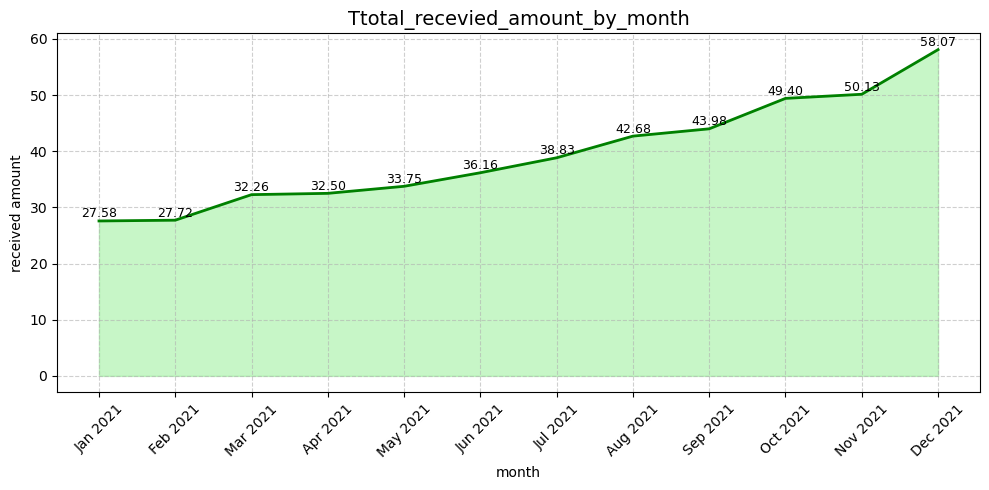

In [111]:
Monthly_recevied=(
    df.sort_values('issue_date')
    .assign(month_name=lambda x:x ['issue_date'].dt.strftime("%b %Y"))
    .groupby('month_name',sort=False)['total_payment']
    .sum()
    .div(1000000)
    .reset_index(name='received_amount_million')
    )
plt.figure(figsize=(10,5))
plt.fill_between(Monthly_recevied['month_name'],Monthly_recevied['received_amount_million'],color='lightgreen',alpha=0.5)
plt.plot(Monthly_recevied['month_name'],Monthly_recevied['received_amount_million'],color='green',linewidth=2)

for i, row in Monthly_recevied.iterrows():
    plt.text(i,row['received_amount_million'] + 0.1,f"{row['received_amount_million']:.2f}",
             ha='center',va='bottom',fontsize=9,rotation=0,color='black')
plt.title('total_recevied_amount_by_month',fontsize=14)
plt.xlabel('month')
plt.ylabel('received amount')
plt.xticks(ticks=range(len(Monthly_recevied)),label=Monthly_recevied['month_name'],rotation=45)
plt.grid(True,linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()


### Monthly trands by issue date for total loan applications

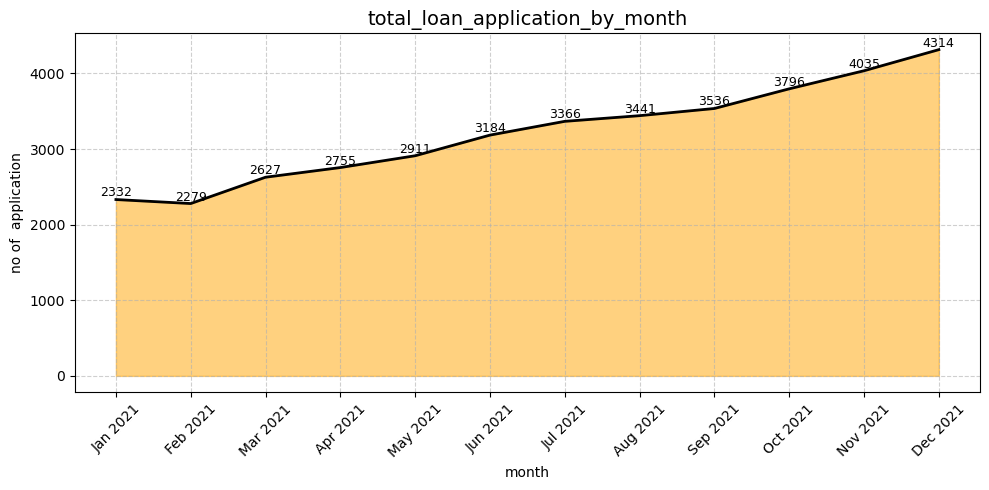

In [122]:
Monthly_application=(
    df.sort_values('issue_date')
    .assign(month_name=lambda x:x ['issue_date'].dt.strftime("%b %Y"))
    .groupby('month_name',sort=False)['id']
    .count()
    .reset_index(name='loan_application_count')
    )
plt.figure(figsize=(10,5))
plt.fill_between(Monthly_application['month_name'],Monthly_application['loan_application_count'],color='orange',alpha=0.5)
plt.plot(Monthly_application['month_name'],Monthly_application['loan_application_count'],color='black',linewidth=2)

for i, row in Monthly_application.iterrows():
    plt.text(i,row['loan_application_count'] + 0.5,f"{row['loan_application_count']}",
             ha='center',va='bottom',fontsize=9,rotation=0,color='black')
plt.title('total_loan_application_by_month',fontsize=14)
plt.xlabel('month')
plt.ylabel('no of  application')
plt.xticks(ticks=range(len(Monthly_application)),label=Monthly_application['month_name'],rotation=45)
plt.grid(True,linestyle='--',alpha=0.6)
plt.tight_layout()
plt.show()


### regional analysis by state for the total funded amount

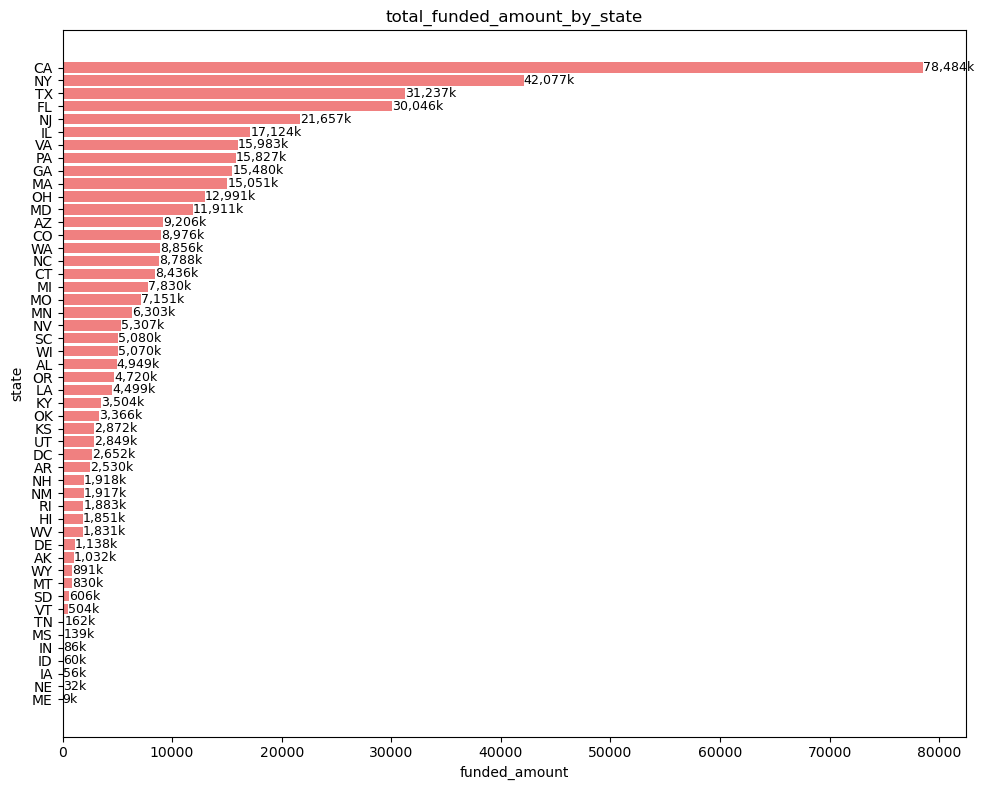

In [125]:
state_funding=df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousand = state_funding/1000

plt.figure(figsize=(10, 8))
bars = plt.barh(state_funding_thousand.index,state_funding_thousand.values,color='lightcoral')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10,bar.get_y() + bar.get_height() /2,
    f'{width:,.0f}k',va='center',fontsize=9)
plt.title('total_funded_amount_by_state')
plt.xlabel('funded_amount')
plt.ylabel('state')
plt.tight_layout()
plt.show()